# Central infinite-assembly model from the BLiu core

This notebook isolates the **central assembly** from the current BLiu full-core model and turns it into a **radially infinite assembly** by applying a **reflective hexagonal boundary** at the assembly pitch.

## What this notebook does
- keeps the **pin geometry**, **materials**, **temperatures**, and **91-pin assembly layout** from the current BLiu model
- selects the **central assembly type** from the full-core layout
- builds **one assembly unit cell** with:
  - fuel-pin lattice
  - wrapper / casing
  - inter-assembly coolant gap up to the periodic boundary
- uses:
  - **reflective** boundary on the outer assembly hex (radial infinity)
  - **vacuum** top and bottom planes (finite axial height)

## Important note
In the full-core layout, the **center position is an inner-fuel assembly**, so the default choice here is `which_assembly = "inner"`.

This notebook is meant to be a clean starting point for comparison against the full-core model and for later simplifications.


In [1]:
%matplotlib inline
import math
import os

import openmc
import numpy as np

# Adjust this path if needed on your local machine
os.environ['OPENMC_CROSS_SECTIONS'] = '/openmc_data/endfb-viii.1-hdf5/cross_sections.xml'
print("OPENMC_CROSS_SECTIONS =", os.environ.get('OPENMC_CROSS_SECTIONS'))


OPENMC_CROSS_SECTIONS = /openmc_data/endfb-viii.1-hdf5/cross_sections.xml


## General parameters

In [2]:
# Temperatures from the current BLiu notebook (ALR version)
T_fuel_in  = 1175.17 + 273.15
T_fuel_out = 1318.55 + 273.15
T_fuel_av  = (T_fuel_in + T_fuel_out) / 2

T_clad_in  = 415.90 + 273.15
T_clad_out = 533.49 + 273.15
T_clad_av  = (T_clad_in + T_clad_out) / 2

T_cool_in  = 400 + 273.15
T_cool_out = 480 + 273.15
T_cool_av  = (T_cool_in + T_cool_out) / 2

# MA fraction in fuel (0 for keff baseline)
percent_MA = 0.0


## Materials

In [3]:
# Blanket UO2 from Liu
blanket_uo2 = openmc.Material(name='Blanket UO2')
blanket_uo2.set_density('g/cm3', 10.97)
blanket_uo2.add_nuclide('U235', 0.00729124, percent_type='ao')
blanket_uo2.add_nuclide('U238', 0.99270876, percent_type='ao')
blanket_uo2.add_element('O', 2.0, percent_type='ao')

# Fuel-side UO2 vector from Liu Table 4 (converted to atomic fractions)
mox_uo2 = openmc.Material(name='Fuel UO2')
mox_uo2.set_density('g/cm3', 10.97)
mox_uo2.add_nuclide('U234', 3.051e-5, percent_type='ao')
mox_uo2.add_nuclide('U235', 4.091e-3, percent_type='ao')
mox_uo2.add_nuclide('U236', 1.008e-4, percent_type='ao')
mox_uo2.add_nuclide('U238', 9.95777e-1, percent_type='ao')
mox_uo2.add_element('O', 2.0, percent_type='ao')

# Fuel PuO2 vector from Liu Table 4 (converted to atomic fractions)
puo2 = openmc.Material(name='Fuel PuO2')
puo2.set_density('g/cm3', 11.5)
puo2.add_nuclide('Pu238', 2.3477e-2, percent_type='ao')
puo2.add_nuclide('Pu239', 5.7015e-1, percent_type='ao')
puo2.add_nuclide('Pu240', 2.6952e-1, percent_type='ao')
puo2.add_nuclide('Pu241', 6.0694e-2, percent_type='ao')
puo2.add_nuclide('Pu242', 7.6164e-2, percent_type='ao')
puo2.add_element('O', 2.0, percent_type='ao')

# Minor actinide mixture (kept for compatibility with later studies)
MA_mix = openmc.Material(name='Minor Actinide Mixture')
MA_mix.set_density('g/cm3', 11.0)
MA_mix.add_nuclide('Np237', 0.5618, percent_type='wo')
MA_mix.add_nuclide('Am241', 0.2640, percent_type='wo')
MA_mix.add_nuclide('Am243', 0.1200, percent_type='wo')
MA_mix.add_nuclide('Cm244', 0.0514, percent_type='wo')
MA_mix.add_nuclide('Cm245', 0.0028, percent_type='wo')

# T91 cladding / wrapper
mat_clad = openmc.Material(name='clad', temperature=T_clad_av)
mat_clad.set_density('g/cm3', 7.76)
mat_clad.add_nuclide('C12', 0.00100, percent_type='wo')
mat_clad.add_element('N', 0.00048, percent_type='wo')
mat_clad.add_element('Al', 0.00022, percent_type='wo')
mat_clad.add_element('Si', 0.00280, percent_type='wo')
mat_clad.add_element('P', 0.00009, percent_type='wo')
mat_clad.add_element('S', 0.00003, percent_type='wo')
mat_clad.add_element('V', 0.00216, percent_type='wo')
mat_clad.add_element('Cr', 0.08370, percent_type='wo')
mat_clad.add_element('Mn', 0.00450, percent_type='wo')
mat_clad.add_element('Fe', 0.89146, percent_type='wo')
mat_clad.add_element('Ni', 0.00210, percent_type='wo')
mat_clad.add_element('Cu', 0.00170, percent_type='wo')
mat_clad.add_element('Nb', 0.00076, percent_type='wo')
mat_clad.add_element('Mo', 0.00900, percent_type='wo')

# Helium gap
mat_gap = openmc.Material(name='helium gap', temperature=(T_fuel_av + T_cool_av)/2)
mat_gap.set_density('g/cm3', 0.0001785)
mat_gap.add_element('He', 1.0)

# Lead coolant
mat_cool = openmc.Material(name='coolant', temperature=T_cool_av)
mat_cool.set_density('g/cm3', 11.34)
mat_cool.add_element('Pb', 1.0)


In [4]:
# Zone-wise UO2 / PuO2 splits from Liu
U_in_fuel  = 0.862 * (1 - percent_MA)
Pu_in_fuel = 0.138 * (1 - percent_MA)

U_mid_fuel  = 0.835 * (1 - percent_MA)
Pu_mid_fuel = 0.165 * (1 - percent_MA)

U_out_fuel  = 0.788 * (1 - percent_MA)
Pu_out_fuel = 0.212 * (1 - percent_MA)

mat_in_fuel = openmc.Material.mix_materials(
    [mox_uo2, puo2, MA_mix],
    [U_in_fuel, Pu_in_fuel, percent_MA],
    percent_type='wo',
    name='internal fuel',
    temperature=T_fuel_in
)

mat_mid_fuel = openmc.Material.mix_materials(
    [mox_uo2, puo2, MA_mix],
    [U_mid_fuel, Pu_mid_fuel, percent_MA],
    percent_type='wo',
    name='middle fuel',
    temperature=T_fuel_av
)

mat_out_fuel = openmc.Material.mix_materials(
    [mox_uo2, puo2, MA_mix],
    [U_out_fuel, Pu_out_fuel, percent_MA],
    percent_type='wo',
    name='outmost fuel',
    temperature=T_fuel_out
)

mat_blan = openmc.Material.mix_materials(
    [blanket_uo2], [1.0],
    percent_type='wo',
    name='blanket',
    temperature=T_cool_av
)

materials = openmc.Materials([
    mat_in_fuel, mat_mid_fuel, mat_out_fuel,
    mat_blan, mat_clad, mat_gap, mat_cool
])
materials.export_to_xml()


## Pin geometry

In [5]:
# Pin geometry (cm)
diam_fuel_pellet = 9.1e-1
thick_clad       = 0.4e-1
out_diam_clad    = 10.4e-1
in_diam_clad     = out_diam_clad - 2 * thick_clad
height_core      = 110.0  # active height used in current full-core model

# Surfaces
surf_fuel_or = openmc.ZCylinder(r=diam_fuel_pellet/2, name='fuel pellet')
surf_clad_ir = openmc.ZCylinder(r=in_diam_clad/2, name='clad inner radius')
surf_clad_or = openmc.ZCylinder(r=out_diam_clad/2, name='clad outer radius')

surf_top = openmc.ZPlane(z0= height_core/2, boundary_type='vacuum', name='top')
surf_bot = openmc.ZPlane(z0=-height_core/2, boundary_type='vacuum', name='bottom')

# Regions
reg_fuel = -surf_top & +surf_bot & -surf_fuel_or
reg_gap  = -surf_top & +surf_bot & +surf_fuel_or & -surf_clad_ir
reg_clad = -surf_top & +surf_bot & +surf_clad_ir & -surf_clad_or
reg_cool = -surf_top & +surf_bot & +surf_clad_or


In [6]:
# Primitive pin cells
cell_in_fuel  = openmc.Cell(fill=mat_in_fuel,  region=reg_fuel, name='fuel, internal')
cell_mid_fuel = openmc.Cell(fill=mat_mid_fuel, region=reg_fuel, name='fuel, middle')
cell_out_fuel = openmc.Cell(fill=mat_out_fuel, region=reg_fuel, name='fuel, outmost')
cell_blan     = openmc.Cell(fill=mat_blan,     region=reg_fuel, name='blanket')

cell_in_gap  = openmc.Cell(fill=mat_gap,  region=reg_gap,  name='gap, internal')
cell_mid_gap = openmc.Cell(fill=mat_gap,  region=reg_gap,  name='gap, middle')
cell_out_gap = openmc.Cell(fill=mat_gap,  region=reg_gap,  name='gap, outmost')
cell_blan_gap = openmc.Cell(fill=mat_gap, region=reg_gap,  name='gap, blanket')

cell_in_clad  = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, internal')
cell_mid_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, middle')
cell_out_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, outmost')
cell_blan_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, blanket')

cell_in_cool  = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, internal')
cell_mid_cool = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, middle')
cell_out_cool = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, outmost')
cell_blan_cool = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, blanket')

cell_empty_cool = openmc.Cell(fill=mat_cool, name='coolant, empty lattice filler')

# Primitive pin universes
uni_in_pin = openmc.Universe(cells=[cell_in_fuel, cell_in_gap, cell_in_clad, cell_in_cool], name='pin, internal')
uni_mid_pin = openmc.Universe(cells=[cell_mid_fuel, cell_mid_gap, cell_mid_clad, cell_mid_cool], name='pin, middle')
uni_out_pin = openmc.Universe(cells=[cell_out_fuel, cell_out_gap, cell_out_clad, cell_out_cool], name='pin, outmost')
uni_blan_pin = openmc.Universe(cells=[cell_blan, cell_blan_gap, cell_blan_clad, cell_blan_cool], name='pin, blanket')
uni_empty_cool = openmc.Universe(cells=[cell_empty_cool], name='coolant filler')


## Assembly lattices

In [7]:
# Assembly-level parameters
pitch_fuel_rod   = 13.6e-1
edge_fuel_ass_in = 5.5 * pitch_fuel_rod
thick_ass_casing = 0.4
edge_fuel_ass_out = edge_fuel_ass_in + 2/math.sqrt(3) * thick_ass_casing

# Same clearance assumption as the full-core notebook
clearance_ass_neigh = 0.5
pitch_core = math.sqrt(3) * edge_fuel_ass_in + 2*thick_ass_casing + clearance_ass_neigh

# Reflective infinite-assembly boundary:
# make the outer reflective hex consistent with the assembly pitch
edge_bc = pitch_core / math.sqrt(3)

print(f"edge_fuel_ass_in  = {edge_fuel_ass_in:.5f} cm")
print(f"edge_fuel_ass_out = {edge_fuel_ass_out:.5f} cm")
print(f"pitch_core        = {pitch_core:.5f} cm")
print(f"edge_bc           = {edge_bc:.5f} cm")


edge_fuel_ass_in  = 7.48000 cm
edge_fuel_ass_out = 7.94188 cm
pitch_core        = 14.25574 cm
edge_bc           = 8.23056 cm


In [8]:
def build_assembly_lattice(name, pin_universe):
    lat = openmc.HexLattice(name=name)
    lat.center = (0., 0.)
    lat.pitch = (pitch_fuel_rod,)
    lat.orientation = 'x'
    lat.outer = uni_empty_cool

    rings = [
        [pin_universe] * (6-1)*6,
        [pin_universe] * (6-2)*6,
        [pin_universe] * (6-3)*6,
        [pin_universe] * (6-4)*6,
        [pin_universe] * (6-5)*6,
        [pin_universe] * 1
    ]
    lat.universes = rings
    return lat

lat_in_fuel  = build_assembly_lattice('internal fuel assembly', uni_in_pin)
lat_mid_fuel = build_assembly_lattice('middle fuel assembly', uni_mid_pin)
lat_out_fuel = build_assembly_lattice('outmost fuel assembly', uni_out_pin)
lat_blan     = build_assembly_lattice('blanket assembly', uni_blan_pin)


In [9]:
# Select assembly type.
# The exact center of the current full-core model is an INNER fuel assembly.
which_assembly = "inner"   # options: "inner", "middle", "outer", "blanket"

lattice_map = {
    "inner": lat_in_fuel,
    "middle": lat_mid_fuel,
    "outer": lat_out_fuel,
    "blanket": lat_blan,
}

selected_lattice = lattice_map[which_assembly]
print("Selected assembly type:", which_assembly)


Selected assembly type: inner


## Infinite-assembly root universe

In [10]:
# Reflective infinite-assembly hex at the assembly pitch
surf_inlat = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_in, orientation='x')
surf_outlat = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_out, orientation='x')
surf_bc = openmc.model.HexagonalPrism(edge_length=edge_bc, orientation='x', boundary_type='reflective')

# Regions
reg_main_lat = -surf_top & +surf_bot & -surf_inlat
reg_wrapper  = -surf_top & +surf_bot & +surf_inlat & -surf_outlat
reg_gap_bc   = -surf_top & +surf_bot & +surf_outlat & -surf_bc

# Cells
cell_main_lat = openmc.Cell(fill=selected_lattice, region=reg_main_lat, name='assembly lattice')
cell_wrapper  = openmc.Cell(fill=mat_clad, region=reg_wrapper, name='assembly wrapper')
cell_gap_bc   = openmc.Cell(fill=mat_cool, region=reg_gap_bc, name='inter-assembly coolant to reflective BC')

uni_root = openmc.Universe(
    cells=[cell_main_lat, cell_wrapper, cell_gap_bc],
    name=f'infinite assembly root: {which_assembly}'
)

geom = openmc.Geometry(uni_root)
geom.export_to_xml()


<Axes: xlabel='x [cm]', ylabel='z [cm]'>

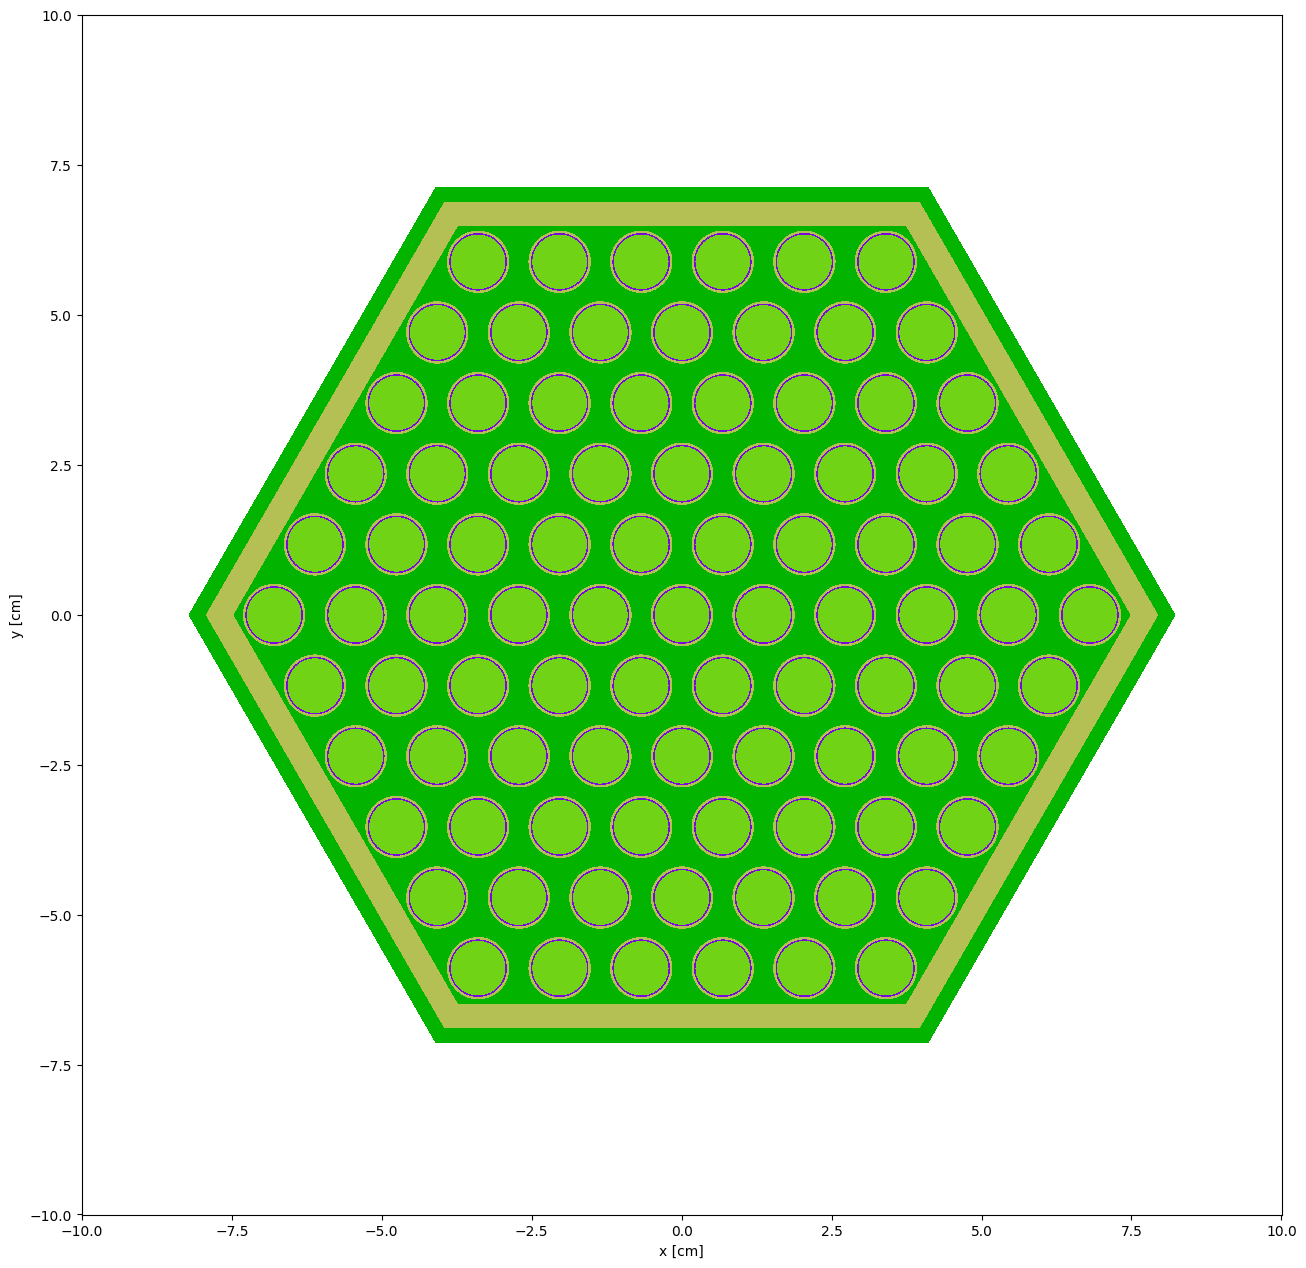

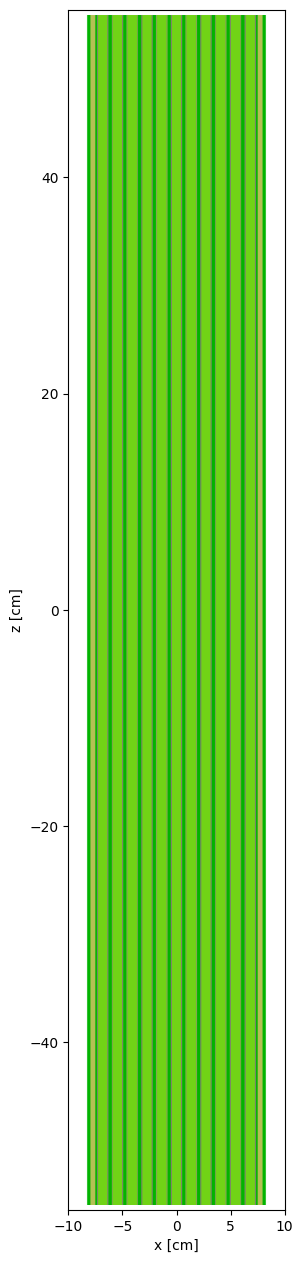

In [11]:
# Plot selected infinite assembly
W_xy = 4.0 * edge_bc / math.sqrt(3.0) + 1.0
W_z  = height_core + 1.0

uni_root.plot(
    origin=(0.0, 0.0, 0.0),
    pixels=(1200, 1200),
    width=(W_xy, W_xy),
    color_by='material'
)

uni_root.plot(
    origin=(0.0, 0.0, 0.0),
    pixels=(1200, 1200),
    width=(W_xy, W_z),
    color_by='material',
    basis='xz'
)


## Simulation settings

In [12]:
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.batches = 200
settings.inactive = 50
settings.particles = 5000

# Simple source box covering the assembly bounding box
box_half = 2.0 * edge_bc / math.sqrt(3.0)
lower_left = (-box_half, -box_half, -height_core/2)
upper_right = ( box_half,  box_half,  height_core/2)

settings.source = openmc.IndependentSource(
    space=openmc.stats.Box(lower_left, upper_right, only_fissionable=True)
)

settings.output = {'tallies': False}
settings.export_to_xml()


/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


## Run OpenMC

In [13]:
RUN_variable = True

if RUN_variable:
    openmc.run()


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

RuntimeError: Nuclear data library does not contain cross sections for C12 at or near 747.845000 K. Available temperatures are 250, 294, 600, 900, 1200, 2500 K. Consider making use of openmc.Settings.temperature to specify how intermediate temperatures are treated. Abort(-1) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, -1) - process 0

## Notes for next discussions

Things you may want to adjust next:
1. `which_assembly` if you want to compare inner / middle / outer / blanket.
2. `clearance_ass_neigh` if you want the reflective boundary to match a different packing assumption.
3. axial boundary treatment if you later want a more assembly-physics-oriented infinite model (for example reflective top/bottom as well).
4. optional tallies for flux spectrum or reaction rates.
